In [47]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt


def build_theta_t_count_dataframe(
    T: float,
    tau_min: float,
    tau_max: float,
    num_grid_points: int
) -> pd.DataFrame:
    """
    Возвращает DataFrame:
        строки  -> theta (точки сетки)
        столбцы -> k
        значения -> количество точек t в допустимом интервале
    """

    grid = np.linspace(0.0, T, num_grid_points)
    K = math.ceil(T / tau_min)

    df = pd.DataFrame(index=grid)

    for k in range(K + 1):

        t_min_k = max(0.0, T - k * tau_max)
        t_max_k = T - k * tau_min

        theta_min_k = t_min_k
        theta_max_k = min(t_max_k + tau_max, T)

        values = []

        for theta in grid:

            # проверяем допустимость theta
            if theta < theta_min_k or theta > theta_max_k:
                values.append(np.nan)
                continue

            t_left = max(theta - tau_max, t_min_k)
            t_right = theta

            mask = (grid >= t_left) & (grid <= t_right)
            values.append(int(mask.sum()))

        df[k] = values

    df.index.name = "theta"

    return df


def plot_task_count_per_points_count(
    T: float,
    tau_min: float,
    tau_max: float,
    num_grid_points_max: int,
    time_per_task: float = 6,
    num_grid_points_min: int = 5,
    log_scale_y: bool = False,
):
    """
    Computes total tasks and computation time for different num_grid_points values
    and produces two plots:
    1. Total task count vs num_grid_points
    2. Computation time (in hours, or days if > 36 hours) vs num_grid_points

    If log_scale_y is True, y-axis is log-scaled on both plots.
    Use this to test for exponential growth: exponential data appears linear on log scale.
    """
    num_grid_points_values = list(range(num_grid_points_min, num_grid_points_max + 1))
    total_tasks_list = []
    total_time_hours_list = []

    for num_grid_points in num_grid_points_values:
        df = build_theta_t_count_dataframe(
            T=T,
            tau_min=tau_min,
            tau_max=tau_max,
            num_grid_points=num_grid_points,
        )
        total_tasks = df.sum().sum() * 2  # For both phases
        total_time_mins = total_tasks * time_per_task
        total_time_hours = total_time_mins / 60
        total_tasks_list.append(total_tasks)
        total_time_hours_list.append(total_time_hours)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # Plot 1: Total task count vs num_grid_points
    ax1.plot(num_grid_points_values, total_tasks_list, "o-")
    ax1.set_xlabel("num_grid_points")
    ax1.set_ylabel("Total tasks")
    ax1.set_title("Total Task Count vs num_grid_points")
    if log_scale_y:
        ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3, which="both" if log_scale_y else "major")

    # Plot 2: Computation time (hours or days if > 36 hours) vs num_grid_points
    use_days = max(total_time_hours_list) > 36
    total_time_display = [h / 24 for h in total_time_hours_list] if use_days else total_time_hours_list
    time_unit = "days" if use_days else "hours"

    ax2.plot(num_grid_points_values, total_time_display, "o-")
    ax2.set_xlabel("num_grid_points")
    ax2.set_ylabel(f"Computation time ({time_unit})")
    ax2.set_title(f"Computation Time vs num_grid_points ({time_unit})")
    if log_scale_y:
        ax2.set_yscale("log")
    ax2.grid(True, alpha=0.3, which="both" if log_scale_y else "major")

    plt.tight_layout()
    plt.show()

In [48]:
df = build_theta_t_count_dataframe(
    T=300,
    tau_min=60,
    tau_max=120,
    num_grid_points=20
)

print(df.head())

            0   1    2    3    4    5
theta                                
0.000000  NaN NaN  NaN  1.0  1.0  1.0
15.789474 NaN NaN  NaN  2.0  2.0  2.0
31.578947 NaN NaN  NaN  3.0  3.0  3.0
47.368421 NaN NaN  NaN  4.0  4.0  4.0
63.157895 NaN NaN  1.0  5.0  5.0  5.0


In [49]:
df

,0,1,2,3,4,5
theta,,,,,,
0.000000,NaN,NaN,NaN,1.0,1.0,1.0
15.789474,NaN,NaN,NaN,2.0,2.0,2.0
31.578947,NaN,NaN,NaN,3.0,3.0,3.0
47.368421,NaN,NaN,NaN,4.0,4.0,4.0
63.157895,NaN,NaN,1.0,5.0,5.0,5.0
78.947368,NaN,NaN,2.0,6.0,6.0,6.0
94.736842,NaN,NaN,3.0,7.0,7.0,7.0
110.526316,NaN,NaN,4.0,8.0,8.0,8.0
126.315789,NaN,NaN,5.0,8.0,8.0,NaN


In [50]:
df.min()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
dtype: float64

In [51]:
df.count()

0     1
1     8
2    16
3    16
4    12
5     8
dtype: int64

In [52]:
df.max()

0    1.0
1    8.0
2    8.0
3    8.0
4    8.0
5    8.0
dtype: float64

In [53]:
total_tasks = df.sum().sum() * 2 # For both phases
time_per_task = 6 # Min
print("Total tasks:", total_tasks)
total_time = total_tasks * time_per_task
print(f"Total time: {total_time} mins = {total_time / 60} hours = {total_time / 60 / 24} days")


Total tasks: 682.0
Total time: 4092.0 mins = 68.2 hours = 2.841666666666667 days


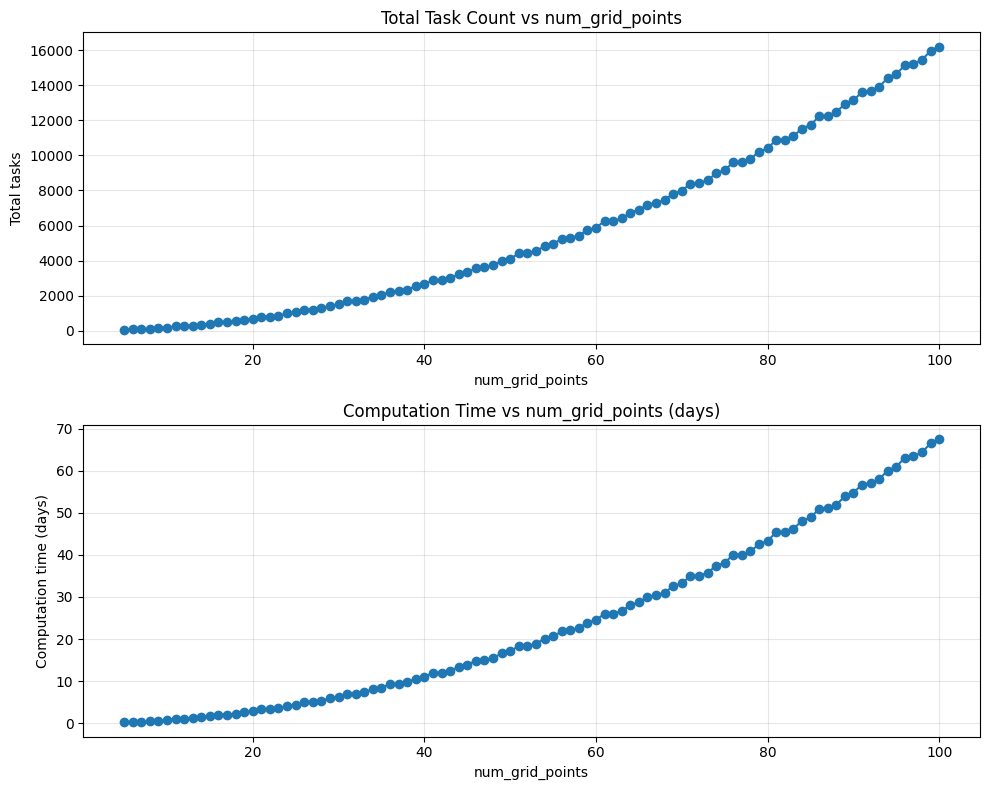

In [56]:
plot_task_count_per_points_count(
    T=300,
    tau_min=60,
    tau_max=120,
    num_grid_points_max=100,
    time_per_task=6,
)